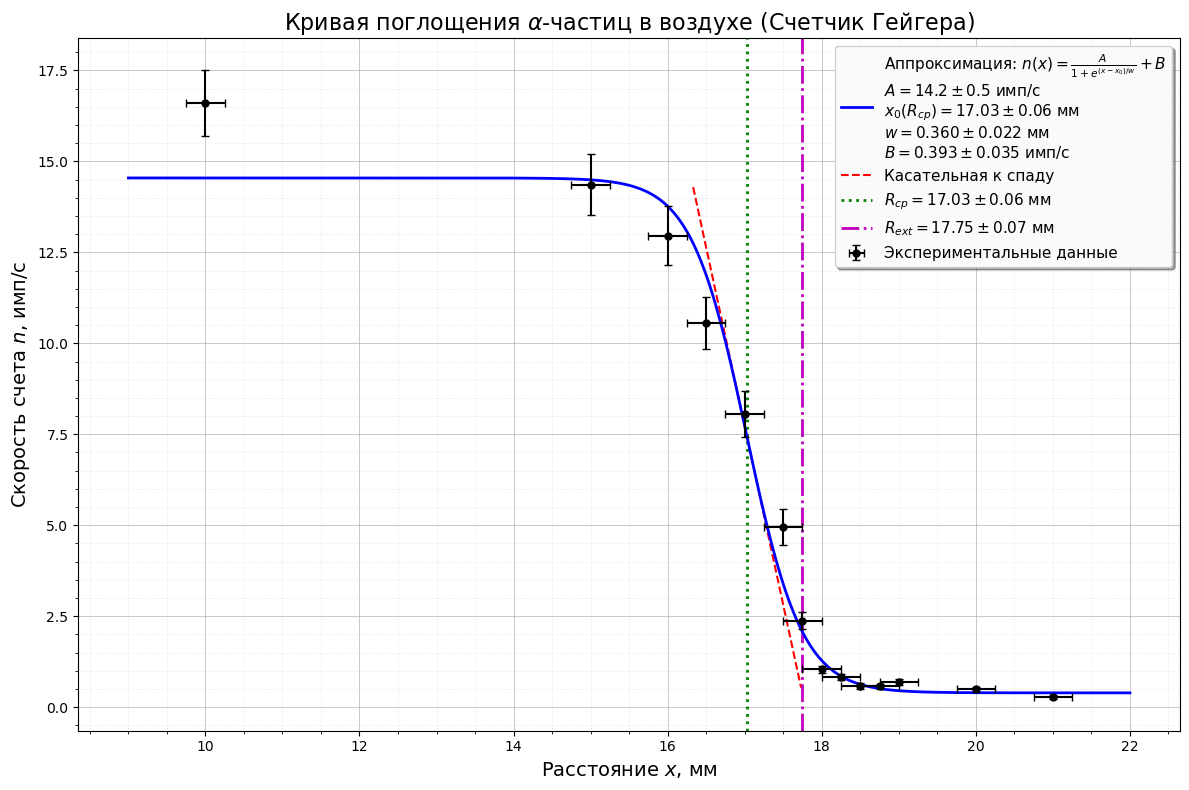

РЕЗУЛЬТАТЫ ИЗМЕРЕНИЙ (В ЛАБОРАТОРНЫХ УСЛОВИЯХ):
--- Средний пробег (R_cp_lab) ---
Raw:      17.025765199885665 +/- 0.05764384531055658 мм
Rounded:  17.03+/-0.06 мм
Rel. Err: 0.34%
--- Экстраполированный пробег (R_ext_lab) ---
Raw:      17.746491080081952 +/- 0.0726786104606975 мм
Rounded:  17.75+/-0.07 мм
Rel. Err: 0.41%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
import uncertainties.unumpy as unp

# --- 1. Входные данные (с фото таблицы) ---
# Расстояние l (мм)
l_mm = np.array([10, 15, 16, 16.5, 17, 17.5, 17.75, 18, 18.25, 18.5, 18.75, 19, 20, 21])
# Время t (с)
t_s = np.array([20.05, 20.19, 19.67, 20.56, 19.85, 19.8, 41.7, 101.3, 99.9, 100.4, 100.3, 105.3, 111.8, 100.2])
# Число импульсов N
N_counts = np.array([333, 290, 255, 217, 160, 98, 99, 105, 83, 59, 57, 73, 55, 27])

# Погрешности
sigma_l = 0.25  # мм (инструментальная)

# Условия опыта
P_lab = 759.07  # Торр
T_lab = 273.15 + 20  # К (принимаем 20 градусов)

# --- 2. Первичная обработка ---
# Скорость счета n = N / t
# Погрешность скорости (статистика Пуассона): sigma_n = sqrt(N) / t
n_val = N_counts / t_s
n_err = np.sqrt(N_counts) / t_s

# Создаем массивы ufloat для удобных расчетов (если понадобятся)
n_u = unp.uarray(n_val, n_err)

# --- 3. Аппроксимация ---
# Модель: Сигмоида (функция Ферми) + фон
def sigmoid(x, A, x0, w, B):
    # x0 - точка перегиба (R_cp)
    return A / (1 + np.exp((x - x0) / w)) + B

# Начальное приближение [Амплитуда, x0, ширина, Фон]
p0 = [max(n_val) - min(n_val), 17.0, 0.5, min(n_val)]

popt, pcov = curve_fit(sigmoid, l_mm, n_val, p0=p0, sigma=n_err, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

# Преобразуем параметры в ufloat
A_u = ufloat(popt[0], perr[0])
x0_u = ufloat(popt[1], perr[1]) # Это R_cp в условиях опыта
w_u = ufloat(popt[2], perr[2])
B_u = ufloat(popt[3], perr[3])

# Рассчитываем Экстраполированный пробег (R_ext)
# R_ext = R_cp + 2 * w
R_cp_lab = x0_u
R_ext_lab = R_cp_lab + 2 * w_u

# --- 4. Вспомогательная функция вывода ---
def print_full_info(name, param_u, unit=""):
    val = param_u.n
    err = param_u.s
    rel_err = (err / abs(val)) * 100 if val != 0 else 0
    print(f"--- {name} ---")
    print(f"Raw:      {val} +/- {err} {unit}")
    print(f"Rounded:  {param_u} {unit}")
    print(f"Rel. Err: {rel_err:.2f}%")

# --- 5. Построение графика ---
plt.figure(figsize=(12, 8))

# Точки
plt.errorbar(l_mm, n_val, xerr=sigma_l, yerr=n_err, fmt='ko', 
             label='Экспериментальные данные', capsize=3, markersize=5, zorder=5)

# Аппроксимация
x_model = np.linspace(min(l_mm)-1, max(l_mm)+1, 400)
y_model = sigmoid(x_model, *popt)

label_fit = (r'Аппроксимация: $n(x) = \frac{A}{1 + e^{(x-x_0)/w}} + B$' + '\n' +
             rf'$A = {A_u:L}$ имп/с' + '\n' +
             rf'$x_0 (R_{{cp}}) = {x0_u:L}$ мм' + '\n' +
             rf'$w = {w_u:L}$ мм' + '\n' +
             rf'$B = {B_u:L}$ имп/с')

plt.plot(x_model, y_model, 'b-', label=label_fit, linewidth=2, zorder=4)

# Касательная
slope = -A_u.n / (4 * w_u.n)
y_tangent_ref = A_u.n / 2 + B_u.n
y_tan = slope * (x_model - x0_u.n) + y_tangent_ref
mask_tan = (y_tan >= B_u.n) & (y_tan <= A_u.n + B_u.n)
plt.plot(x_model[mask_tan], y_tan[mask_tan], 'r--', linewidth=1.5, label='Касательная к спаду')

# Вертикальные линии
plt.axvline(x=R_cp_lab.n, color='g', linestyle=':', linewidth=2, label=rf'$R_{{cp}} = {R_cp_lab:L}$ мм')
plt.axvline(x=R_ext_lab.n, color='m', linestyle='-.', linewidth=2, label=rf'$R_{{ext}} = {R_ext_lab:L}$ мм')

plt.xlabel(r'Расстояние $x$, мм', fontsize=14)
plt.ylabel(r'Скорость счета $n$, имп/с', fontsize=14)
plt.title(r'Кривая поглощения $\alpha$-частиц в воздухе (Счетчик Гейгера)', fontsize=16)
plt.minorticks_on()
plt.grid(which='major', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95, shadow=True)
plt.tight_layout()

plt.savefig("./plot_pogl.pdf")
plt.show()

# --- 6. Вывод результатов ---
print("="*50)
print("РЕЗУЛЬТАТЫ ИЗМЕРЕНИЙ (В ЛАБОРАТОРНЫХ УСЛОВИЯХ):")
print_full_info("Средний пробег (R_cp_lab)", R_cp_lab, "мм")
print_full_info("Экстраполированный пробег (R_ext_lab)", R_ext_lab, "мм")
print("="*50)

In [2]:
# Константы нормальных условий
P0 = 760.0
T0 = 273.15 + 15

# Коэффициент пересчета
k_norm = (P_lab / P0) * (T0 / T_lab)

R_cp_0 = R_cp_lab * k_norm
R_ext_0 = R_ext_lab * k_norm

print(f"Коэффициент пересчета k: {k_norm:.4f}")
print("="*40)
print_full_info("Средний пробег (привед. к н.у.) R_cp_0", R_cp_0, "мм")
print_full_info("Экстрап. пробег (привед. к н.у.) R_ext_0", R_ext_0, "мм")

Коэффициент пересчета k: 0.9817
--- Средний пробег (привед. к н.у.) R_cp_0 ---
Raw:      16.71489298696724 +/- 0.05659133051651134 мм
Rounded:  16.71+/-0.06 мм
Rel. Err: 0.34%
--- Экстрап. пробег (привед. к н.у.) R_ext_0 ---
Raw:      17.422459185548412 +/- 0.07135157697935329 мм
Rounded:  17.42+/-0.07 мм
Rel. Err: 0.41%


In [3]:
rho_air = 1.225 # мг/см^3

# Переводим мм в см (делим на 10)
R_ext_mass = (R_ext_0 / 10) * rho_air

print_full_info("Массовый экстраполированный пробег", R_ext_mass, "мг/см^2")

--- Массовый экстраполированный пробег ---
Raw:      2.1342512502296804 +/- 0.00874056817997078 мг/см^2
Rounded:  2.134+/-0.009 мг/см^2
Rel. Err: 0.41%


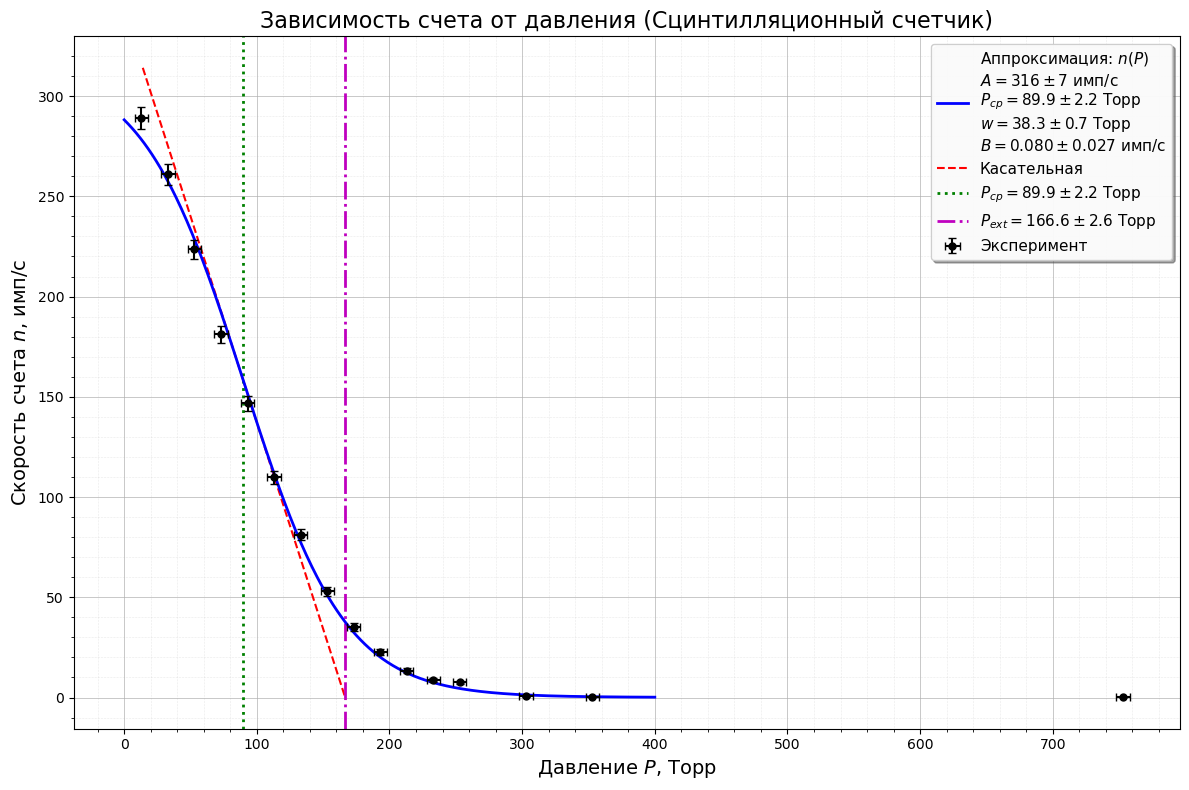

РЕЗУЛЬТАТЫ ЧАСТИ II (Сцинтиллятор):
--- Экстраполированное давление P_ext ---
Raw:      166.56913819757307 +/- 2.5824990575002995 Торр
Rounded:  166.6+/-2.6 Торр
Rel. Err: 1.55%
------------------------------
--- Полный пробег R_ext (II) ---
Raw:      19.38885582846379 +/- 0.30060611734465026 мм
Rounded:  19.39+/-0.30 мм
Rel. Err: 1.55%
СРАВНЕНИЕ МЕТОДОВ И ОЦЕНКА СЛЮДЫ:
Пробег I (Гейгер, остаточный): 17.42 \pm 0.07 мм
Пробег II (Сцинтиллятор, полный): 19.39 \pm 0.30 мм
--- Разница пробегов (Delta R_air) ---
Raw:      1.9663966429153774 +/- 0.30895806401915815 мм
Rounded:  1.97+/-0.31 мм
Rel. Err: 15.71%
--- Толщина слюды окна ---
Raw:      0.28906030650856046 +/- 0.045416835410816245 мг/см^2
Rounded:  0.29+/-0.05 мг/см^2
Rel. Err: 15.71%


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
import uncertainties.unumpy as unp

# --- 1. Входные данные (Сцинтилляционный счетчик) ---
P_torr = np.array([13, 33, 53, 73, 93, 113, 133, 153, 173, 193, 213, 233, 253, 303, 353, 753])
t_scint_s = np.array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 100, 200])
N_scint = np.array([2892, 2610, 2236, 1812, 1468, 1099, 812, 529, 352, 229, 134, 86, 76, 7, 20, 34])

# Параметры установки
L_chamber = 90.0  # мм (Фиксированное расстояние, 9 см)
P0 = 760.0        # Нормальное давление
T0 = 288.15       # 15 C
T_lab = 293.15    # 20 C

# Погрешности
sigma_P = 5.0 # Торр

# --- 2. Обработка ---
n_scint = N_scint / t_scint_s
n_scint_err = np.sqrt(N_scint) / t_scint_s

# Модель (падающая сигмоида)
def sigmoid_pressure(x, A, x0, w, B):
    # При малом x (давлении) знаменатель ~1 -> n = A + B
    # При большом x знаменатель большой -> n = B
    return A / (1 + np.exp((x - x0) / w)) + B

# Начальное приближение
# Амплитуда ~ 280, перегиб где-то на 120 Торр, ширина ~ 20, фон ~ 0
p0 = [280, 120, 20, 0.2]

popt, pcov = curve_fit(sigmoid_pressure, P_torr, n_scint, p0=p0, sigma=n_scint_err, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

# Ufloat параметры
A_u = ufloat(popt[0], perr[0])
P_cp_u = ufloat(popt[1], perr[1]) # Давление полуспада
w_u = ufloat(popt[2], perr[2])
B_u = ufloat(popt[3], perr[3])

# Экстраполированное ДАВЛЕНИЕ (P_ext)
# Так как график падающий, касательная пересекает фон СПРАВА от перегиба.
# Формула та же: x0 + 2w
P_ext_u = P_cp_u + 2 * w_u

# --- 3. Пересчет давления в пробег (R_ext) ---
# Если частица пролетает L=90мм при давлении P_ext,
# то при P0 она пролетела бы:
R_ext_II = L_chamber * (P_ext_u / P0) * (T0 / T_lab)

# --- 4. Вспомогательная функция вывода ---
def print_full_info(name, param_u, unit=""):
    val = param_u.n
    err = param_u.s
    rel_err = (err / abs(val)) * 100 if val != 0 else 0
    print(f"--- {name} ---")
    print(f"Raw:      {val} +/- {err} {unit}")
    print(f"Rounded:  {param_u} {unit}")
    print(f"Rel. Err: {rel_err:.2f}%")

# --- 5. Построение графика ---
plt.figure(figsize=(12, 8))

plt.errorbar(P_torr, n_scint, xerr=sigma_P, yerr=n_scint_err, fmt='ko', 
             label='Эксперимент', capsize=3, markersize=5, zorder=5)

x_model = np.linspace(0, 400, 400) # Ограничим до 400, т.к. дальше фон
y_model = sigmoid_pressure(x_model, *popt)

label_fit = (r'Аппроксимация: $n(P)$' + '\n' +
             rf'$A = {A_u:L}$ имп/с' + '\n' +
             rf'$P_{{cp}} = {P_cp_u:L}$ Торр' + '\n' +
             rf'$w = {w_u:L}$ Торр' + '\n' +
             rf'$B = {B_u:L}$ имп/с')

plt.plot(x_model, y_model, 'b-', label=label_fit, linewidth=2, zorder=4)

# Касательная
slope = -A_u.n / (4 * w_u.n)
y_ref = A_u.n / 2 + B_u.n
y_tan = slope * (x_model - P_cp_u.n) + y_ref
mask_tan = (y_tan >= B_u.n) & (y_tan <= A_u.n + B_u.n)
plt.plot(x_model[mask_tan], y_tan[mask_tan], 'r--', linewidth=1.5, label='Касательная')

# Линии P_cp и P_ext
plt.axvline(x=P_cp_u.n, color='g', linestyle=':', linewidth=2, label=rf'$P_{{cp}} = {P_cp_u:L}$ Торр')
plt.axvline(x=P_ext_u.n, color='m', linestyle='-.', linewidth=2, label=rf'$P_{{ext}} = {P_ext_u:L}$ Торр')

plt.xlabel(r'Давление $P$, Торр', fontsize=14)
plt.ylabel(r'Скорость счета $n$, имп/с', fontsize=14)
plt.title(r'Зависимость счета от давления (Сцинтилляционный счетчик)', fontsize=16)
plt.minorticks_on()
plt.grid(which='major', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95, shadow=True)
plt.tight_layout()

plt.savefig("plot2.pdf")
plt.show()

# --- 6. Результаты и Сравнение ---
print("="*50)
print("РЕЗУЛЬТАТЫ ЧАСТИ II (Сцинтиллятор):")
print_full_info("Экстраполированное давление P_ext", P_ext_u, "Торр")
print("-" * 30)
print_full_info("Полный пробег R_ext (II)", R_ext_II, "мм")
print("="*50)

# Сравнение с Частью I (взято из предыдущего шага, впиши вручную значение R_ext_0, если нужно, но тут я возьму переменную)
# Предположим R_ext_I из прошлого запуска доступен как R_ext_0
# Если переменная потерялась, впиши значение вручную: R_ext_I = ufloat(17.42, 0.07)

R_ext_I = R_ext_0 

print("СРАВНЕНИЕ МЕТОДОВ И ОЦЕНКА СЛЮДЫ:")
print(f"Пробег I (Гейгер, остаточный): {R_ext_I:L} мм")
print(f"Пробег II (Сцинтиллятор, полный): {R_ext_II:L} мм")

# Разница пробегов (эквивалентная толщина слюды в воздухе)
Delta_R_air = R_ext_II - R_ext_I
print_full_info("Разница пробегов (Delta R_air)", Delta_R_air, "мм")

# Пересчет в толщину слюды (мг/см2)
# Методичка: "пробег в слюде (в мг/см2) в 1.2 раза больше, чем в воздухе"
# Значит, тормозная способность слюды чуть меньше.
# Толщина слюды d_mica [мг/см2] = Delta_R_air [см] * rho_air [мг/см3] * 1.2
rho_air = 1.225 # мг/см3
d_mica = (Delta_R_air / 10) * rho_air * 1.2

print_full_info("Толщина слюды окна", d_mica, "мг/см^2")
print("="*50)

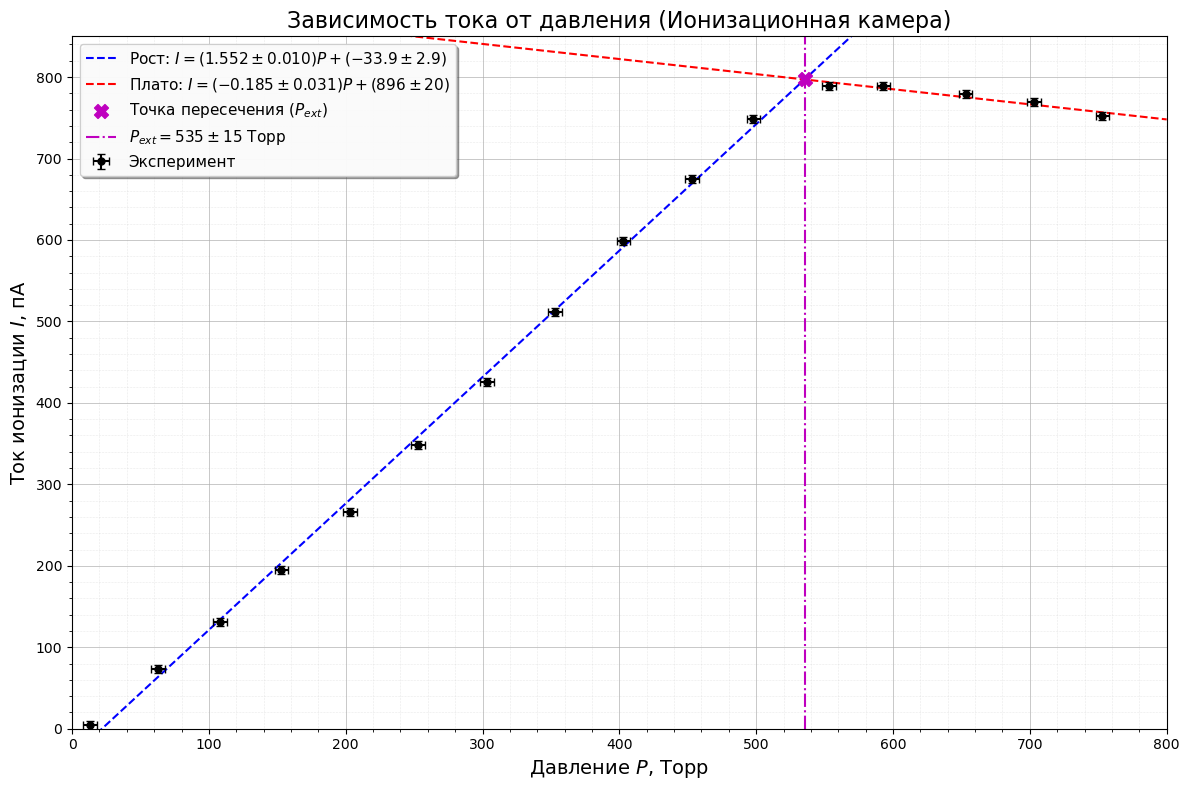

РЕЗУЛЬТАТЫ ЧАСТИ III (Ионизационная камера):
--- Давление пересечения P_ext ---
Raw:      535.332549075405 +/- 15.462008457294813 Торр
Rounded:  535+/-15 Торр
Rel. Err: 2.89%
------------------------------
--- Пробег R (прив. к н.у.) ---
Raw:      34.618543142112884 +/- 0.9998872808445246 мм
Rounded:  34.6+/-1.0 мм
Rel. Err: 2.89%
--- Рассчитанная энергия E_alpha ---
Raw:      4.891467880198345 +/- 0.09418683503408581 МэВ
Rounded:  4.89+/-0.09 МэВ
Rel. Err: 1.93%


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
import uncertainties.unumpy as unp

# --- 1. Входные данные (Ионизационная камера) ---
P_raw = np.array([13, 63, 108, 153, 203, 253, 303, 353, 403, 453, 498, 553, 593, 653, 703, 753])
I_raw = np.array([5, 74, 132, 196, 267, 349, 427, 513, 600, 676, 750, 790, 790, 780, 770, 753])

# Погрешности и константы
I_bg = 1.0       # Фоновой ток (вычитаем его)
sigma_I = 5.0    # пА
sigma_P = 5.0    # Торр
R_sph = 50.0     # мм (Радиус камеры, диаметр 100 мм)
P0 = 760.0       # Нормальное давление
T0 = 288.15      # 15 C
T_lab = 293.15   # 20 C (оценка)

# Вычитание фона
I_val = I_raw - I_bg
# Пересчет погрешностей в uarray не обязателен для curve_fit, но полезен для понимания
I_u = unp.uarray(I_val, sigma_I)

# --- 2. Разделение на участки ---
# Визуально:
# Рост идет примерно до 498 Торр (индекс 10)
# Плато начинается примерно с 553 Торр (индекс 11)
# Мы оставим небольшой зазор или включим пограничные точки в фит по усмотрению.
# Попробуем разбить так:
idx_rise_end = 11  # Включая точку 498 в рост
idx_plat_start = 11 # Начиная с 553 (индекс 11) - плато

P_rise = P_raw[:idx_rise_end]
I_rise = I_val[:idx_rise_end]

P_plat = P_raw[idx_plat_start:]
I_plat = I_val[idx_plat_start:]

# --- 3. Линейная аппроксимация ---
def linear(x, k, b):
    return k * x + b

# Фит роста
popt_rise, pcov_rise = curve_fit(linear, P_rise, I_rise, sigma=[sigma_I]*len(I_rise), absolute_sigma=True)
perr_rise = np.sqrt(np.diag(pcov_rise))
k1_u = ufloat(popt_rise[0], perr_rise[0])
b1_u = ufloat(popt_rise[1], perr_rise[1])

# Фит плато
popt_plat, pcov_plat = curve_fit(linear, P_plat, I_plat, sigma=[sigma_I]*len(I_plat), absolute_sigma=True)
perr_plat = np.sqrt(np.diag(pcov_plat))
k2_u = ufloat(popt_plat[0], perr_plat[0])
b2_u = ufloat(popt_plat[1], perr_plat[1])

# --- 4. Поиск пересечения (P_ext) ---
# k1*P + b1 = k2*P + b2  =>  P(k1 - k2) = b2 - b1
P_cross_u = (b2_u - b1_u) / (k1_u - k2_u)
I_cross_u = k1_u * P_cross_u + b1_u

# --- 5. Пересчет в пробег ---
# При давлении P_cross пробег равен R_sph (50 мм).
# Пересчитываем в нормальные условия:
R_ion_0 = R_sph * (P_cross_u / P0) * (T0 / T_lab)

# --- 6. Функция вывода (та же) ---
def print_full_info(name, param_u, unit=""):
    val = param_u.n
    err = param_u.s
    rel_err = (err / abs(val)) * 100 if val != 0 else 0
    print(f"--- {name} ---")
    print(f"Raw:      {val} +/- {err} {unit}")
    print(f"Rounded:  {param_u} {unit}")
    print(f"Rel. Err: {rel_err:.2f}%")

# --- 7. График ---
plt.figure(figsize=(12, 8))

# Точки
plt.errorbar(P_raw, I_val, xerr=sigma_P, yerr=sigma_I, fmt='ko', 
             label='Эксперимент', capsize=3, markersize=5, zorder=5)

# Линии аппроксимации
x_model = np.linspace(0, 800, 200)

# Рост (зеленый)
plt.plot(x_model, linear(x_model, *popt_rise), 'b--', linewidth=1.5,
         label=rf'Рост: $I = ({k1_u:L})P + ({b1_u:L})$')

# Плато (красный)
plt.plot(x_model, linear(x_model, *popt_plat), 'r--', linewidth=1.5,
         label=rf'Плато: $I = ({k2_u:L})P + ({b2_u:L})$')

# Точка пересечения
plt.scatter(P_cross_u.n, I_cross_u.n, s=100, c='m', marker='X', zorder=6, 
            label='Точка пересечения ($P_{ext}$)')
plt.axvline(P_cross_u.n, color='m', linestyle='-.', label=rf'$P_{{ext}} = {P_cross_u:L}$ Торр')

plt.xlabel(r'Давление $P$, Торр', fontsize=14)
plt.ylabel(r'Ток ионизации $I$, пА', fontsize=14)
plt.title(r'Зависимость тока от давления (Ионизационная камера)', fontsize=16)

plt.minorticks_on()
plt.grid(which='major', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)
plt.legend(fontsize=11, loc='best', framealpha=0.95, shadow=True)

plt.xlim(0, 800)
plt.ylim(0, 850)
plt.tight_layout()

plt.savefig("plot3.pdf")
plt.show()

# --- 8. Вывод результатов ---
print("="*50)
print("РЕЗУЛЬТАТЫ ЧАСТИ III (Ионизационная камера):")
print_full_info("Давление пересечения P_ext", P_cross_u, "Торр")
print("-" * 30)
print_full_info("Пробег R (прив. к н.у.)", R_ion_0, "мм")
print("="*50)

# --- 9. Определение энергии ---
# Формула (12): R = 0.32 * E^(3/2)  =>  E = (R / 0.32)^(2/3)
# R в см!
R_cm = R_ion_0 / 10
E_alpha = (R_cm / 0.32) ** (2/3)

print_full_info("Рассчитанная энергия E_alpha", E_alpha, "МэВ")
print("="*50)

In [16]:
import numpy as np

# --- Расчет количества вещества (Пункт 8, Часть II) ---

# 1. Исходные данные
N_max = A_u  # Максимальная скорость счета из аппроксимации (имп/с) сцинтиллятора
# Если переменная A_u перезаписалась, введи вручную: 
# N_max = ufloat(316, 7) 

Omega = 0.04          # Телесный угол (стерадиан) [cite: 220]
T_half_years = 2.44e4 # Период полураспада Pu-239 (лет) [cite: 152]
mu_Pu = 239.0         # Молярная масса Pu-239 (г/моль)
N_A = 6.022e23        # Число Авогадро

# 2. Полная активность источника (Activity)
# Детектор видит только Omega, а частицы летят в 4*pi
# A_total = N_max * (4 * pi / Omega)
Total_Activity = N_max * (4 * np.pi / Omega)

# 3. Постоянная распада lambda
# Переводим годы в секунды
seconds_in_year = 365.25 * 24 * 3600
T_half_sec = T_half_years * seconds_in_year
lam = np.log(2) / T_half_sec

# 4. Число ядер N_nuclei
# A_total = lam * N_nuclei  => N_nuclei = A_total / lam
N_nuclei = Total_Activity / lam

# 5. Масса вещества m
# m = (N_nuclei / N_A) * mu
mass_g = (N_nuclei / N_A) * mu_Pu
mass_ug = mass_g * 1e6 # Перевод в микрограммы

# --- Вывод ---
print("="*50)
print("ОЦЕНКА КОЛИЧЕСТВА ВЕЩЕСТВА (ЗАДАНИЕ II, П.8):")
print(f"Максимальный счет (в угле {Omega} ср): {N_max:L} имп/с")
print(f"Полная активность источника: {Total_Activity:.2e} Бк")
print("-" * 30)
print(f"Масса плутония-239: {mass_ug:L} мкг")
print("="*50)

ОЦЕНКА КОЛИЧЕСТВА ВЕЩЕСТВА (ЗАДАНИЕ II, П.8):
Максимальный счет (в угле 0.04 ср): 316 \pm 7 имп/с
Полная активность источника: (9.92+/-0.22)e+04 Бк
------------------------------
Масса плутония-239: 43.7 \pm 1.0 мкг


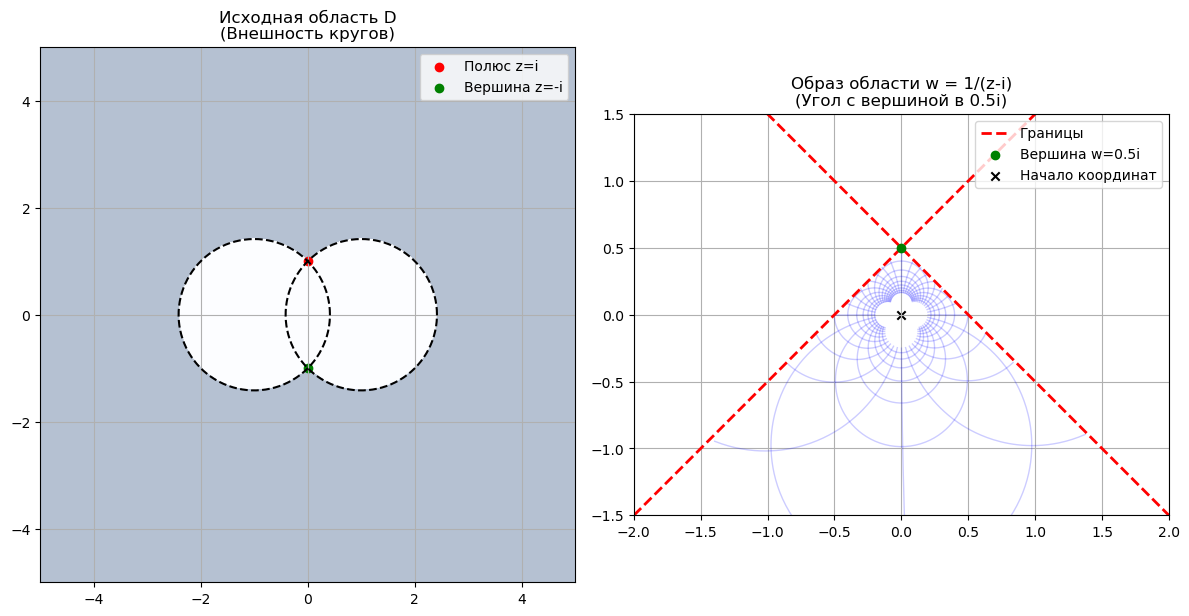

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def transform_func(z):
    # w = 1 / (z - i)
    with np.errstate(divide='ignore', invalid='ignore'):
        w = 1.0 / (z - 1j)
    return w

# 1. Подготовка координатной сетки
# Берем область побольше, так как "внешность" уходит в бесконечность
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# 2. Маска для области D (внешность двух кругов)
# Круг 1: |z + 1| <= sqrt(2)
# Круг 2: |z - 1| <= sqrt(2)
mask_D = ~( (np.abs(Z + 1) <= np.sqrt(2)) | (np.abs(Z - 1) <= np.sqrt(2)) | ((Z.real == 0) & (1 <= Z.imag) & (Z.imag <= 2)))

# Применяем маску к сетке
Z_masked = np.ma.masked_where(~mask_D, Z)

# 3. Вычисляем отображение
W = transform_func(Z_masked)

# 4. Построение графиков
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- Исходная плоскость Z ---
ax[0].set_title("Исходная область D\n(Внешность кругов)")
# Границы кругов
theta = np.linspace(0, 2*np.pi, 200)
ax[0].plot(-1 + np.sqrt(2)*np.cos(theta), np.sqrt(2)*np.sin(theta), 'k--')
ax[0].plot(1 + np.sqrt(2)*np.cos(theta), np.sqrt(2)*np.sin(theta), 'k--')
# Заливка области
ax[0].imshow(mask_D, extent=[-5, 5, -5, 5], origin='lower', cmap='Blues', alpha=0.3)
ax[0].scatter([0], [1], c='red', label='Полюс z=i')
ax[0].scatter([0], [-1], c='green', label='Вершина z=-i')
ax[0].legend()
ax[0].grid(True)
ax[0].set_aspect('equal')

# --- Плоскость образа W ---
ax[1].set_title("Образ области w = 1/(z-i)\n(Угол с вершиной в 0.5i)")

# Для красивой отрисовки образа берем линии сетки из Z
# Горизонтальные и вертикальные линии исходной сетки
for k in range(0, 500, 25): # прореживаем линии
    # Линии x = const
    line_v = Z[:, k]
    line_v = np.ma.masked_where(~mask_D[:, k], line_v)
    w_line_v = transform_func(line_v)
    ax[1].plot(w_line_v.real, w_line_v.imag, 'b-', alpha=0.2, lw=1)
    
    # Линии y = const
    line_h = Z[k, :]
    line_h = np.ma.masked_where(~mask_D[k, :], line_h)
    w_line_h = transform_func(line_h)
    ax[1].plot(w_line_h.real, w_line_h.imag, 'b-', alpha=0.2, lw=1)

# Рисуем теоретические границы (прямые)
# Уравнения прямых: v = u + 0.5 и v = -u + 0.5
u_vals = np.linspace(-2, 2, 100)
ax[1].plot(u_vals, u_vals + 0.5, 'r--', lw=2, label='Границы')
ax[1].plot(u_vals, -u_vals + 0.5, 'r--', lw=2)

ax[1].scatter([0], [0.5], c='green', zorder=5, label='Вершина w=0.5i')
ax[1].scatter([0], [0], c='black', marker='x', label='Начало координат')

ax[1].set_xlim(-2, 2)
ax[1].set_ylim(-1.5, 1.5)
ax[1].legend()
ax[1].grid(True)
ax[1].set_aspect('equal')

plt.tight_layout()
plt.show()

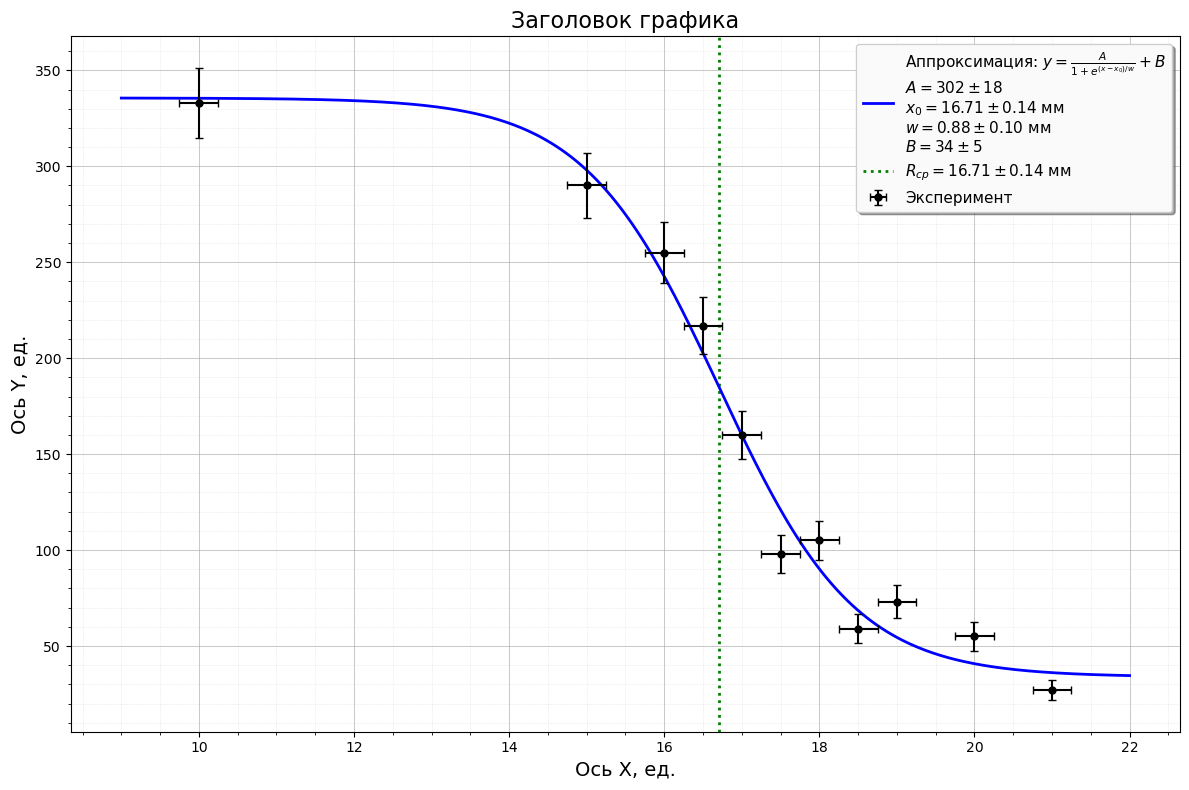

РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ И РАСЧЕТОВ:
--------------------
--- Параметр A ---
Raw:      301.7329591177781 +/- 18.190191540682793 имп/с
Rounded:  302+/-18 имп/с
Rel. Err: 6.03%
--- Параметр x0 (R_cp) ---
Raw:      16.709383308765734 +/- 0.14014902209241786 мм
Rounded:  16.71+/-0.14 мм
Rel. Err: 0.84%
--- Параметр w ---
Raw:      0.8768497794073103 +/- 0.10246525523593057 мм
Rounded:  0.88+/-0.10 мм
Rel. Err: 11.69%
--- Параметр B ---
Raw:      33.86409742247774 +/- 5.1356744646325785 имп/с
Rounded:  34+/-5 имп/с
Rel. Err: 15.17%
--------------------
--- Средний пробег (R_cp) ---
Raw:      16.709383308765734 +/- 0.14014902209241786 мм
Rounded:  16.71+/-0.14 мм
Rel. Err: 0.84%
--- Экстраполированный (R_ext) ---
Raw:      18.463082867580354 +/- 0.2482705429883268 мм
Rounded:  18.46+/-0.25 мм
Rel. Err: 1.34%


In [3]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from uncertainties import ufloat



# --- Вспомогательная функция для вывода (ОБЯЗАТЕЛЬНО) ---

def print_full_info(name, param_u, unit=""):

    """Выводит полную статистику по параметру ufloat"""

    val = param_u.n

    err = param_u.s

    rel_err = (err / abs(val)) * 100 if val != 0 else 0

    

    print(f"--- {name} ---")

    print(f"Raw:      {val} +/- {err} {unit}")

    print(f"Rounded:  {param_u} {unit}")

    print(f"Rel. Err: {rel_err:.2f}%")



# --- 1. Входные данные (Пример) ---

# Бот заменяет это на данные пользователя

x_data = np.array([10, 15, 16, 16.5, 17, 17.5, 18, 18.5, 19, 20, 21])

y_data = np.array([333, 290, 255, 217, 160, 98, 105, 59, 73, 55, 27])

y_err = np.sqrt(y_data)

x_err = 0.25



# --- 2. Модель ---

def model_func(x, A, x0, w, B):

    return A / (1 + np.exp((x - x0) / w)) + B



p0 = [max(y_data), np.mean(x_data), 1, min(y_data)]

popt, pcov = curve_fit(model_func, x_data, y_data, p0=p0, sigma=y_err, absolute_sigma=True)

perr = np.sqrt(np.diag(pcov))



# --- 3. Работа с uncertainties ---

# Преобразуем все параметры в ufloat

A_u = ufloat(popt[0], perr[0])

x0_u = ufloat(popt[1], perr[1])

w_u = ufloat(popt[2], perr[2])

B_u = ufloat(popt[3], perr[3])



# Расчет физических величин

R_cp = x0_u

R_ext = x0_u + 2 * w_u



# --- 4. Построение графика ---

plt.figure(figsize=(12, 8))



# Точки

plt.errorbar(x_data, y_data, xerr=x_err, yerr=y_err, fmt='ko', 

             label='Эксперимент', capsize=3, markersize=5, zorder=5)



# Аппроксимация

x_model = np.linspace(min(x_data)-1, max(x_data)+1, 400)

y_model = model_func(x_model, *popt)



# Легенда с формулой и параметрами

label_fit = (r'Аппроксимация: $y = \frac{A}{1 + e^{(x-x_0)/w}} + B$' + '\n' +

             rf'$A = {A_u:L}$' + '\n' +

             rf'$x_0 = {x0_u:L}$ мм' + '\n' +

             rf'$w = {w_u:L}$ мм' + '\n' +

             rf'$B = {B_u:L}$')



plt.plot(x_model, y_model, 'b-', label=label_fit, linewidth=2, zorder=4)



# Доп. линии

plt.axvline(x=R_cp.n, color='g', linestyle=':', linewidth=2, label=rf'$R_{{cp}} = {R_cp:L}$ мм')



# Оформление

plt.xlabel(r'Ось X, ед.', fontsize=14)

plt.ylabel(r'Ось Y, ед.', fontsize=14)

plt.title(r'Заголовок графика', fontsize=16)

plt.minorticks_on()

plt.grid(which='major', linewidth=0.7, alpha=0.7)

plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)

plt.legend(fontsize=11, loc='upper right', framealpha=0.95, shadow=True)

plt.tight_layout()

plt.savefig("example.pdf")

plt.show()



# --- 5. Вывод результатов (Полный отчет) ---

print("="*50)

print("РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ И РАСЧЕТОВ:")

print("-" * 20)

# Вывод параметров модели

print_full_info("Параметр A", A_u, "имп/с")

print_full_info("Параметр x0 (R_cp)", x0_u, "мм")

print_full_info("Параметр w", w_u, "мм")

print_full_info("Параметр B", B_u, "имп/с")

print("-" * 20)

# Вывод рассчитанных величин

print_full_info("Средний пробег (R_cp)", R_cp, "мм")

print_full_info("Экстраполированный (R_ext)", R_ext, "мм")

print("="*50)